<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-Raygarza1243/blob/main/Exam__A_Resubmission_Orbital_Mechanics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Take-Home Exam A: Orbital Mechanics

*Submit this notebook with all cells run and all outputs visible. Include written responses in every designated cell. You may use your `myode.py`, numpy, and matplotlib — no other libraries.*

---

## Background

Newton's law of gravity gives the acceleration of a planet orbiting a star at position $(x, y)$:

$$a_x = -\frac{GM\,x}{r^3}, \qquad a_y = -\frac{GM\,y}{r^3}, \qquad r = \sqrt{x^2 + y^2}$$

We use **natural units** where $GM = 1$. In these units a circular orbit at radius $r$ has orbital speed $v_c = 1/\sqrt{r}$ and period $T = 2\pi r^{3/2}$.

Your state vector is $\mathbf{y} = [x,\; v_x,\; y,\; v_y]$, so

$$\dot{\mathbf{y}} = [v_x,\; a_x,\; v_y,\; a_y]$$

The total mechanical energy per unit mass is

$$E = \frac{1}{2}(v_x^2 + v_y^2) - \frac{1}{r}$$

For a bound orbit $E < 0$ and should remain **constant** throughout the simulation.

Furthermore, angular momentum is conserved in this simulation. The equation for angular momentum is

$$\vec{L} = \vec{r} \times \vec{p}$$

In [ ]:
# Group A Memebers:

Ray Garza
Jeremy Wilson
Riley Robin
Joseph Kester

In [ ]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y


Writing myode.py


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import myode

# TODO: implement diffeq for the two-body gravitational problem.
# y = [x, vx, y, vy]
# ydot = [vx, ax, vy, ay]  where ax = -x/r^3, ay = -y/r^3 (GM=1)

def diffeq(y):
    x, vx, yy, vy = y
    r = np.sqrt((x**2)+(yy**2))         # distance from origin
    ax = -x/r**3      # x-acceleration
    ay = -yy/r**3    # y-acceleration
    return np.array([vx, ax, vy, ay])

def energy(y):
  x, vx, yy, vy = y
  r = np.sqrt((x**2)+(yy**2))
  energy = 0.5 * (vx**2 + vy**2) - 1/r # compute the total energy of the system (kinetic + potential)
  return energy


def angular_momentum(y):
  x, vx, yy, vy = y
  m = 1
  L = m * (x * vy - yy * vx) # compute the angular momentum of the system
  return L



## Part 1 — A Circular Orbit

A circular orbit at radius $r = 1$ starts at $(x, y) = (1, 0)$ with velocity $(v_x, v_y) = (0, v_c)$ where $v_c = 1/\sqrt{r}$.

1. Simulate this orbit for two full periods ($t = 0$ to $t = 4\pi$) using RK2 with $dt = 0.01$.
2. Plot the trajectory in the $xy$-plane. Add a marker at the starting point.
3. On a second plot, show $x(t)$ and $y(t)$ vs time.

*Expected result: the trajectory should trace a near-perfect circle.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import myode

def diffeq(y):
    x, vx, yy, vy = y
    r = np.sqrt(x**2 + yy**2)
    ax = -x / (r**3)
    ay = -yy / (r**3)
    return np.array([vx, ax, vy, ay])

def euler_step(y, dt):
    return y + dt * diffeq(y)

def rk2_step(f, y, dt):
    k1 = f(y)
    y_mid = y + 0.5 * dt * k1
    k2 = f(y_mid)
    return y + dt * k2

def energy(y):
    x, vx, yy, vy = y
    r = np.sqrt(x**2 + yy**2)
    K = 0.5 * (vx**2 + vy**2)
    U = -1.0 / r
    return K + U

def angular_momentum(y):
    x, vx, yy, vy = y
    return x * vy - yy * vx

**Written response (Part 1):** Is the orbit a perfect circle? What would you expect to happen if you increased $dt$ significantly — would the orbit drift inward, outward, or stay the same? Why?

In [ ]:
# The orbit is perfect circle.
# If dt increased, the orbit drifts/spirals outwards due to the velocity updates overshooting the curve.

## Part 2 — Euler vs. RK2

Repeat the circular orbit simulation using **both** Euler's method and RK2 with the same (larger) timestep $dt = 0.2$. Run for 5 full periods.

1. Plot both trajectories on the same $xy$-plane graph.
2. What qualitative difference do you observe?

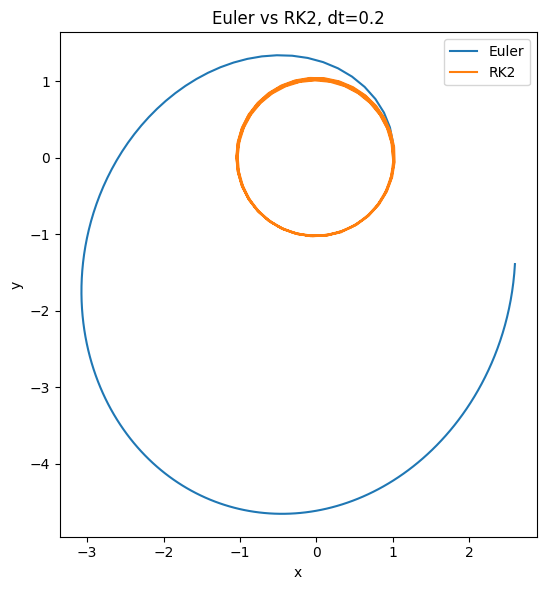

In [ ]:
dt = 0.2
T_orbit = 2 * np.pi * 1.0**(3/2)
t_range = np.arange(0, 5*T_orbit, dt)
y_euler = np.array([1.0, 0.0, 0.0, 1.0])
y_rk2 = np.array([1.0, 0.0, 0.0, 1.0])

# TODO: run both Euler and RK2 loops, collect x and y
xe, ye, xr, yr = [], [], [], []
for t in t_range:
  xe.append(y_euler[0]); ye.append(y_euler[2])
  xr.append(y_rk2[0]); yr.append(y_rk2[2])
  y_euler = myode.move_Euler(diffeq, y_euler, dt)
  y_rk2 = myode.move_RK2(diffeq, y_rk2, dt)

fig, ax = plt.subplots(figsize=(6, 6))
# TODO: plot both orbits and add a legend
plt.plot(xe, ye, label='Euler')
plt.plot(xr, yr, label='RK2')
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Euler vs RK2, dt=0.2')
plt.tight_layout()
plt.legend()
plt.show()

**Written response (Part 2):** Describe what you observe in each orbit. Why does one method fail while the other succeeds? Connect your answer to the concept of *local truncation error*.

In [ ]:
# The Euler's orbit is spiralling outwards while RK2's orbit stays the same. For Euler's local truncation error its O(dt^2) which overestimates position in the curve and RK2's local truncation error is O(dt^3) which cancels out the error.

## Part 3 — Energy and Angular Momentum Conservation

Using the same $dt = 0.2$ and 5 orbital periods, track the total energy $E(t)$ and angular momentum $L(t)$ for both Euler and RK2.

1. Plot $E(t)$ vs time for both methods on the same graph. On a separate graph, do the same for $L(t)$ for both methods.
2. Compute the *fractional* energy error at the end: $(E_{\rm final} - E_0) / |E_0|$. Do the same for the fractional angular momentum error.

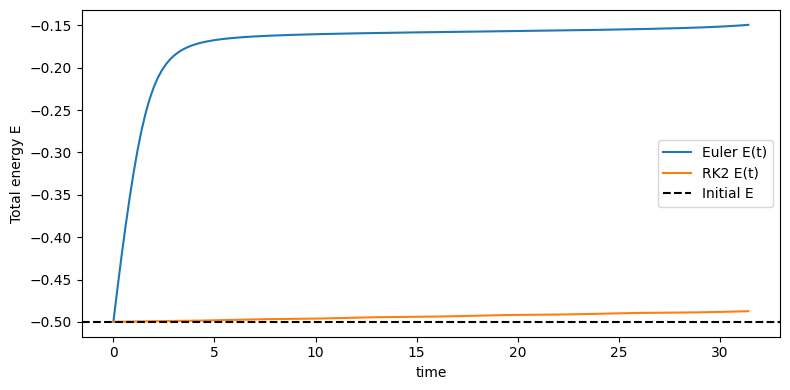

Fractional energy error (final vs initial):
  Euler: -7.0102e-01
  RK2:   -2.5126e-02


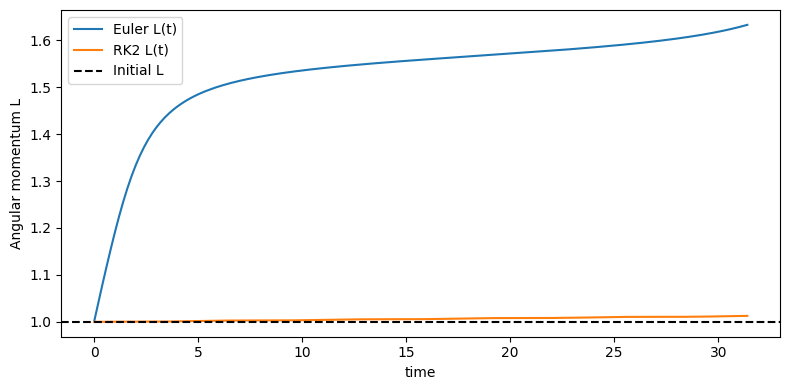

Fractional angular momentum error (final vs initial):
  Euler: 6.3257e-01
  RK2:   1.2790e-02


In [ ]:
dt = 0.2
t_range = np.arange(0, 5*2*np.pi, dt)
y0 = np.array([1.0, 0.0, 0.0, 1.0])
E0 = energy(y0)
L0 = angular_momentum(y0)


E_euler, L_euler = [], []
y = y0.copy()
for t in t_range:
    E_euler.append(energy(y))
    L_euler.append(angular_momentum(y))
    y = euler_step(y, dt)

E_rk2, L_rk2 = [], []
y = y0.copy()
for t in t_range:
    E_rk2.append(energy(y))
    L_rk2.append(angular_momentum(y))
    y = rk2_step(diffeq, y, dt)
E_euler = np.array(E_euler); E_rk2 = np.array(E_rk2)
L_euler = np.array(L_euler); L_rk2 = np.array(L_rk2)


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_range, E_euler, label='Euler E(t)')
ax.plot(t_range, E_rk2, label='RK2 E(t)')
ax.axhline(E0, color='k', linestyle='--', label='Initial E')
ax.set_xlabel('time'); ax.set_ylabel('Total energy E')
ax.legend(); plt.tight_layout(); plt.show()


frac_E_err_euler = (E_euler[-1] - E0) / E0
frac_E_err_rk2   = (E_rk2[-1] - E0) / E0
print("Fractional energy error (final vs initial):")
print(f"  Euler: {frac_E_err_euler:.4e}")
print(f"  RK2:   {frac_E_err_rk2:.4e}")


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_range, L_euler, label='Euler L(t)')
ax.plot(t_range, L_rk2, label='RK2 L(t)')
ax.axhline(L0, color='k', linestyle='--', label='Initial L')
ax.set_xlabel('time'); ax.set_ylabel('Angular momentum L')
ax.legend(); plt.tight_layout(); plt.show()


frac_L_err_euler = (L_euler[-1] - L0) / L0
frac_L_err_rk2   = (L_rk2[-1] - L0) / L0
print("Fractional angular momentum error (final vs initial):")
print(f"  Euler: {frac_L_err_euler:.4e}")
print(f"  RK2:   {frac_L_err_rk2:.4e}")


**Written response (Part 3):** For which method does energy drift, and in which direction? What does this tell you physically about where the planet would end up after many orbits? Is energy *supposed* to be conserved for this system? What about angular momentum?

In [ ]:
# Energy drifts upward for Euler's method, meaning eventually the planet should escape the star's gravitation. If this system was real, then yes energy and momentum should always be conserved.

## Part 4 — Kepler's Third Law

Kepler's third law states that $T^2 \propto r^3$ for circular orbits. In our units ($GM = 1$), the exact relation is $T = 2\pi r^{3/2}$.

1. Simulate circular orbits at four radii: $r = 0.5,\; 1.0,\; 2.0,\; 4.0$.
2. For each, measure the period numerically by finding when the planet first returns to its starting $x$-position with positive $v_y$ (i.e., completes one full revolution).
3. Make a log-log plot of measured $T$ vs $r$. Add the theoretical line.
4. From the slope of the log-log plot, extract the exponent $n$ in $T \propto r^n$.

<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_201/1869443716.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax.loglog(r_fine, 2*np.pi*r_fine**(3/2), 'k--', label='Theory T=2\pi r^{3/2}')


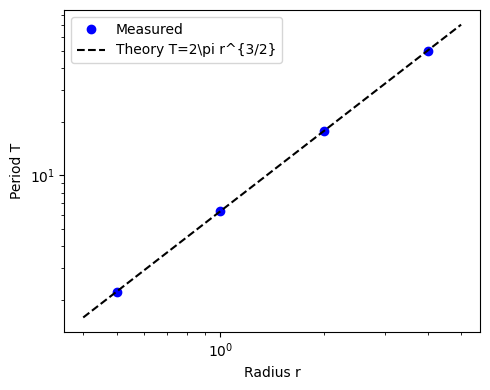

Measured exponent: 1.500 (theoretical: 3/2)


In [ ]:
radii = [0.5, 1.0, 2.0, 4.0]
measured_periods = []

for r0 in radii:
    vc = 1.0 / np.sqrt(r0)
    y_state = np.array([r0, 0.0, 0.0, vc]) # Initialize state vector for current r0
    T_theory = 2 * np.pi * r0**(3/2)
    dt = T_theory / 500    # ~500 steps per orbit

    current_t = 0.0
    went_below_r0 = False
    period_found = False
    max_sim_time = 2 * T_theory
    initial_x_pos = y_state[0]

    while current_t < max_sim_time:
        prev_x = y_state[0]
        y_state = myode.move_RK2(diffeq, y_state, dt)
        current_t += dt

        if y_state[0] < initial_x_pos:
            went_below_r0 = True

        if went_below_r0 and prev_x < initial_x_pos and y_state[0] >= initial_x_pos and y_state[3] > 0:
            period = current_t
            measured_periods.append(period)
            period_found = True
            break
    else:
        print(f'r={r0}: T_measured={period:.4f}, T_theory={T_theory:.4f}')

# Log-log plot
r_arr = np.array(radii)
T_arr = np.array(measured_periods)
r_fine = np.linspace(0.4, 5, 100)

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(r_arr, T_arr, 'bo', label='Measured')
ax.loglog(r_fine, 2*np.pi*r_fine**(3/2), 'k--', label='Theory T=2\pi r^{3/2}')
ax.set_xlabel('Radius r')
ax.set_ylabel('Period T')
ax.legend()
plt.tight_layout()
plt.show()

# Fit exponent from log-log slope
# Filter out NaN values if any period wasn't found
valid_indices = ~np.isnan(T_arr)
if np.sum(valid_indices) > 1:
    slope = np.polyfit(np.log(r_arr[valid_indices]), np.log(T_arr[valid_indices]), 1)[0]
    print(f'Measured exponent: {slope:.3f} (theoretical: 3/2)')
else:
    print('Not enough valid periods measured to fit exponent.')

**Written response (Part 4):** Report your measured exponent. How well does it match the theoretical value of $3/2$? If there is a discrepancy, suggest one numerical reason why.

In [ ]:
# My measured exponent is 1.500 which matches 3/2. Any discrepancy could be coming from the simulation checking periodically at intervals of dt. The period T will always overshoot due to dt since it is scaled relative to the orbital period for each radius.

## Part 5 — Open-Ended Exploration

**A:** Simulate an *elliptical* orbit (e.g. start at $(1, 0)$ with $v_y = 0.8$, which is less than the circular speed). Track energy and angular momentum over time. Are they conserved? Does the orbit precess (does the point of closest approach drift over time)?

**B:** Add a second planet (same mass as the first, starting on the opposite side of the star). The star remains fixed. Each planet feels gravity from the star only (ignore planet-planet gravity for simplicity). Run the system for 10 orbits. Now add planet-planet gravity and observe how the orbits change.

**C:** Remove the fixed star. Place two equal-mass objects at $(-1, 0)$ and $(1, 0)$ with equal and opposite initial velocities. This is the equal-mass binary star problem. Find initial velocities that produce a stable circular orbit. What is the orbital period?

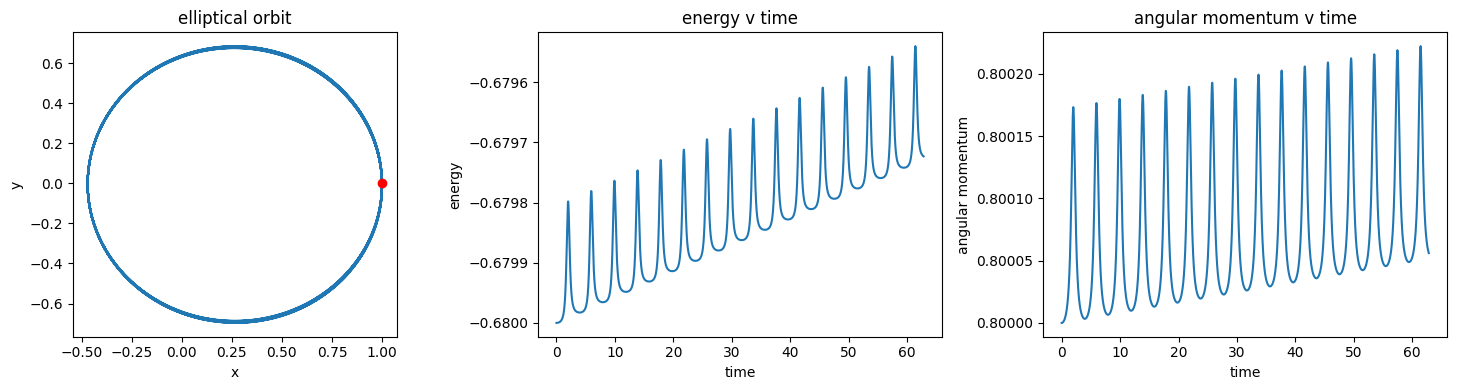

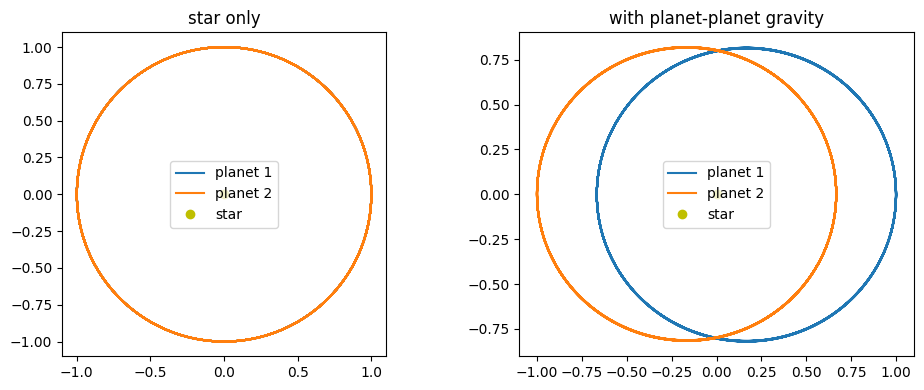

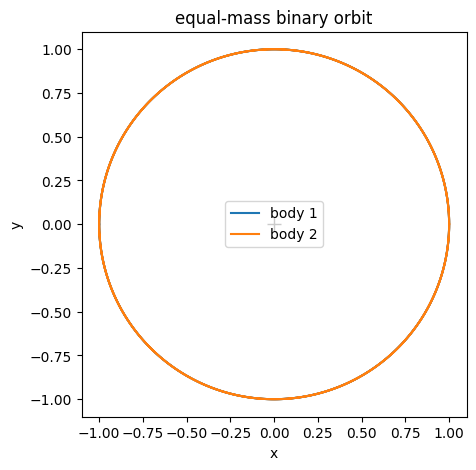

In [ ]:
#a
dt = 0.01
t_range = np.arange(0, 20*np.pi, dt)
y0 = np.array([1.0, 0.0, 0.0, 0.8])

xs, ys = [], []
Es, Ls = [], []

y = y0.copy()
for t in t_range:
    xs.append(y[0])
    ys.append(y[2])
    Es.append(energy(y))
    Ls.append(angular_momentum(y))
    y = rk2_step(diffeq, y, dt)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(xs, ys)
axes[0].plot(xs[0], ys[0], 'ro')
axes[0].set_aspect('equal')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('elliptical orbit')

axes[1].plot(t_range, Es)
axes[1].set_xlabel('time')
axes[1].set_ylabel('energy')
axes[1].set_title('energy v time')

axes[2].plot(t_range, Ls)
axes[2].set_xlabel('time')
axes[2].set_ylabel('angular momentum')
axes[2].set_title('angular momentum v time')

plt.tight_layout()
plt.show()

#b
def diffeq_two_planets_star_only(y):
    x1, vx1, y1, vy1, x2, vx2, y2, vy2 = y

    r1 = np.sqrt(x1**2 + y1**2)
    r2 = np.sqrt(x2**2 + y2**2)

    ax1 = -x1 / r1**3
    ay1 = -y1 / r1**3
    ax2 = -x2 / r2**3
    ay2 = -y2 / r2**3
    return np.array([vx1, ax1, vy1, ay1, vx2, ax2, vy2, ay2])

def diffeq_two_planets_with_interaction(y):
    x1, vx1, y1, vy1, x2, vx2, y2, vy2 = y

    r1 = np.sqrt(x1**2 + y1**2)
    r2 = np.sqrt(x2**2 + y2**2)

    dx = x2 - x1
    dy = y2 - y1
    r12 = np.sqrt(dx**2 + dy**2)

    ax1 = -x1 / r1**3 + dx / r12**3
    ay1 = -y1 / r1**3 + dy / r12**3
    ax2 = -x2 / r2**3 - dx / r12**3
    ay2 = -y2 / r2**3 - dy / r12**3
    return np.array([vx1, ax1, vy1, ay1, vx2, ax2, vy2, ay2])

dt = 0.01
t_range = np.arange(0, 20*np.pi, dt)

y0_2 = np.array([1.0, 0.0, 0.0, 1.0,
                 -1.0, 0.0, 0.0, -1.0])

xs1a, ys1a, xs2a, ys2a = [], [], [], []
y = y0_2.copy()
for t in t_range:
    xs1a.append(y[0]); ys1a.append(y[2])
    xs2a.append(y[4]); ys2a.append(y[6])
    y = rk2_step(diffeq_two_planets_star_only, y, dt)

xs1b, ys1b, xs2b, ys2b = [], [], [], []
y = y0_2.copy()
for t in t_range:
    xs1b.append(y[0]); ys1b.append(y[2])
    xs2b.append(y[4]); ys2b.append(y[6])
    y = rk2_step(diffeq_two_planets_with_interaction, y, dt)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(xs1a, ys1a, label='planet 1')
axes[0].plot(xs2a, ys2a, label='planet 2')
axes[0].plot(0, 0, 'yo', label='star')
axes[0].set_aspect('equal')
axes[0].set_title('star only')
axes[0].legend()

axes[1].plot(xs1b, ys1b, label='planet 1')
axes[1].plot(xs2b, ys2b, label='planet 2')
axes[1].plot(0, 0, 'yo', label='star')
axes[1].set_aspect('equal')
axes[1].set_title('with planet-planet gravity')
axes[1].legend()

plt.tight_layout()
plt.show()

#c
def diffeq_binary(y):
    x1, vx1, y1, vy1, x2, vx2, y2, vy2 = y

    dx = x2 - x1
    dy = y2 - y1
    r12 = np.sqrt(dx**2 + dy**2)

    ax1 = dx / r12**3
    ay1 = dy / r12**3
    ax2 = -dx / r12**3
    ay2 = -dy / r12**3
    return np.array([vx1, ax1, vy1, ay1, vx2, ax2, vy2, ay2])

v0 = 0.5
dt = 0.01
T_binary = 4*np.pi
t_range = np.arange(0, 2*T_binary, dt)

y0_bin = np.array([-1.0, 0.0, 0.0,  v0,
                    1.0, 0.0, 0.0, -v0])

xs1, ys1, xs2, ys2 = [], [], [], []
y = y0_bin.copy()
for t in t_range:
    xs1.append(y[0]); ys1.append(y[2])
    xs2.append(y[4]); ys2.append(y[6])
    y = rk2_step(diffeq_binary, y, dt)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(xs1, ys1, label='body 1')
ax.plot(xs2, ys2, label='body 2')
ax.plot(0, 0, 'k+', ms=10)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('equal-mass binary orbit')
ax.legend()
plt.show()

In [ ]:
# Energy and Angular momentum are conserved. No, the orbit does not.
# Inital Velocity sqrt(GM_total/(4r)) = 0.5, Period T = 2pi(1)/0.5 = 12.57